# Máquinas Térmicas - Lección 7
## Máquinas hidráulicas de desplazamiento positivo (Compresores y turbinas reciprocantes)

**Autor:** Camilo Bayona  
**Fecha:** 02/09/2025

### Objetivos de aprendizaje

1. Interpretar el diagrama $P-V$ de un compresor de desplazamiento positivo y relacionarlo con el trabajo específico de compresión $W=\int P\mathrm{d}V$.

2. Calcular el trabajo del compresor ideal y real, incorporando el efecto del volumen de holgura (volumen residual) y las pérdidas asociadas a las válvulas.

3. Definir, deducir y aplicar la eficiencia volumétrica $\eta_v$; evaluar cómo cambia con la relación de presiones y el volumen de holgura.

4. Comparar el ciclo ideal vs. el ciclo real de compresión (politrópico/isentrópico) y determinar la temperatura de descarga y la potencia requerida.

5. Diseñar esquemas de multietapas de compresión con enfriamiento intermedio; calcular la presión intermedia óptima y estimar la reducción del trabajo total.

6. Emplear la eficiencia isentrópica del compresor $\eta_c=\dfrac{h_{2s}-h_1}{h_{2r}-h_1}$ para estimar desempeño y potencia.

7. Reconocer y comparar principios de operación, ventajas y limitaciones de compresores reciprocantes y rotativos (Roots y Lysholm), identificando sus campos de aplicación.

8. Resolver un problema de dimensionamiento básico que requiera el cálculo del trabajo, $\eta_v$, temperaturas y potencia, verificando coherencia dimensional y notación unificada en SI.

##1. Introducción

El elemento de impartición de energía no tiene que tener necesariamente movimiento
alternativo (émbolo), sino que puede tener movimiento rotativo (rotor).
Sin embargo, en las máquinas de desplazamiento positivo tanto alternativas como rotativas, siempre hay una cámara que aumenta de volumen
(succión en una bomba) o disminuye de volumen (impulsión). Por eso se llaman también máquinas volumetricas.

In [ ]:
# Colab-friendly animated piston + live P–V curve (fixed scalar→sequence)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML, display

rc('animation', html='jshtml')  # render animations as JS/HTML in Colab

# -----------------------------
# Parameters
# -----------------------------
rpm       = 600          # crank speed
n_poly    = 1.30         # polytropic index
P_amb     = 101325.0     # Pa
T_amb     = 300.0        # K
bore      = 0.08         # m
stroke    = 0.09         # m
conrod    = 0.15         # m
CR        = 9.0
Rgas      = 287.0        # J/(kg·K)
frames    = 360

# -----------------------------
# Geometry & thermodynamics
# -----------------------------
R = stroke / 2.0
A = 0.25 * np.pi * bore**2
Vd = A * stroke
Vc = Vd / (CR - 1.0)

theta = np.linspace(0, 2*np.pi, frames, endpoint=False)
omega = -2*np.pi * rpm/60.0
t = theta / omega
dt_ms = 1000.0 * (t[1] - t[0])

def x_from_TDC(th):
    # Slider-crank piston top position from TDC
    return (R + conrod) - (R*np.cos(th) + np.sqrt(conrod**2 - (R*np.sin(th))**2))

x = x_from_TDC(theta)
V = Vc + A * x

# BDC state at theta ≈ π
i_bdc = np.argmin(np.abs(theta - np.pi))
V_bdc, P_bdc, T_bdc = V[i_bdc], P_amb, T_amb
m = P_bdc * V_bdc / (Rgas * T_bdc)

# Polytropic compression (π→2π) and expansion (0→π)
P = np.zeros_like(V)
Cc = P_bdc * (V_bdc**n_poly)
mask_comp = theta >= np.pi
P[mask_comp] = Cc / (V[mask_comp]**n_poly)

i_tdc = 0
V_tdc = V[i_tdc]
P_tdc = Cc / (V_tdc**n_poly)
Ce = P_tdc * (V_tdc**n_poly)
P[~mask_comp] = Ce / (V[~mask_comp]**n_poly)

T = P * V / (m * Rgas)
V_L, P_bar = 1e3 * V, P / 1e5  # helpful plotting units

# -----------------------------
# Figure 1: piston–cylinder
# -----------------------------
fig1, ax1 = plt.subplots()
ax1.set_aspect('equal')
cyl_height = stroke + 0.02
ax1.set_xlim(-bore*0.75, bore*0.75)
ax1.set_ylim(-0.02, cyl_height + 0.02)
ax1.set_xlabel('Cylinder cross-section [m]')
ax1.set_ylabel('Height [m]')
ax1.set_title('Piston Motion (Compression–Expansion)')
ax1.add_line(plt.Line2D([-bore/2, -bore/2], [0, cyl_height]))
ax1.add_line(plt.Line2D([ bore/2,  bore/2], [0, cyl_height]))
ax1.add_line(plt.Line2D([-bore/2,  bore/2], [cyl_height, cyl_height]))

piston_thickness = 0.01
piston_face = plt.Rectangle((-bore/2, x[0]), bore, piston_thickness)
ax1.add_patch(piston_face)
txt1 = ax1.text(0.0, cyl_height+0.015, '', ha='center', va='bottom')

def init_fig1():
    piston_face.set_y(x[0])
    txt1.set_text('')
    return piston_face, txt1

def animate_fig1(i):
    piston_face.set_y(x[i])
    txt1.set_text(
        f'θ={np.degrees(theta[i]):.0f}°   V={V[i]*1e6:.1f} cm³   P={P[i]/1e5:.2f} bar   T={T[i]:.1f} K'
    )
    return piston_face, txt1

anim1 = animation.FuncAnimation(
    fig1, animate_fig1, init_func=init_fig1,
    frames=frames, interval=dt_ms, blit=True, repeat=True
)

# -----------------------------
# Figure 2: live P–V curve
# -----------------------------
fig2, ax2 = plt.subplots()
ax2.set_xlabel('Volume [L]')
ax2.set_ylabel('Pressure [bar]')
ax2.set_title('P–V Diagram (live)')
ax2.grid(True)
line_pv, = ax2.plot([], [], '-', lw=2)
dot_pv,  = ax2.plot([], [], 'o')  # keep as Line2D marker
ax2.set_xlim(V_L.min()*0.95, V_L.max()*1.05)
ax2.set_ylim(P_bar.min()*0.9, P_bar.max()*1.1)

def init_fig2():
    line_pv.set_data([], [])
    dot_pv.set_data([], [])  # both x,y empty sequences
    return line_pv, dot_pv

def animate_fig2(i):
    # IMPORTANT: pass sequences (lists/arrays), not scalars
    line_pv.set_data(V_L[:i+1], P_bar[:i+1])
    dot_pv.set_data([V_L[i]], [P_bar[i]])  # <-- fixed: wrap in lists
    return line_pv, dot_pv

anim2 = animation.FuncAnimation(
    fig2, animate_fig2, init_func=init_fig2,
    frames=frames, interval=dt_ms, blit=True, repeat=True
)

# Render as JS/HTML in Colab
plt.close(fig1); plt.close(fig2)
display(HTML(anim1.to_jshtml()))
display(HTML(anim2.to_jshtml()))


### 1.1. Diagrama $P$ - $V$


En el diagrama de presión contra volumen la línea $d$-$a$ representa la carrera de succión. La masa en el cilindro aumenta desde cero en $d$ hasta la cantidad requerida para llenar el cilindro en $a$.

En el caso ideal, la temperatura se mantiene constante en $T_1$ durante este proceso y no hay intercambio de calor con el entorno.

La succión comienza cuando la diferencia de presión a través de la válvula es suficiente para abrirla.

La línea $abc$ representa la carrera de compresión y entrega.

A medida que el pistón comienza su carrera de retorno, la presión en el cilindro aumenta y cierra la válvula de entrada.

El aumento de presión continúa con el pistón en retorno, como se muestra en la línea $ab$, hasta que se alcanza la presión en la que se abre la válvula de entrega (un valor determinado por la válvula y la presión en el receptor).

La entrega tiene lugar según lo muestra la línea $bc$, que es un proceso a temperatura constante $T_2$, presión constante $p_2$, intercambio de calor nulo y masa decreciente.

Al final de esta carrera, se repite el ciclo. El valor de la temperatura de entrega $T_2$ depende de la ley de compresión entre $a$ y $b$, que a su vez depende del intercambio de calor con el entorno durante este proceso. Puede suponerse que la forma general de compresión es la politrópica reversible con lo que :

$$pV^n = cte$$

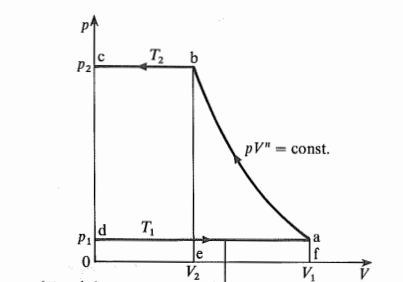

###1.2. Trabajo del compresor



La potencia requerida para operar un compresor alternativo puede dividirse en tres componentes: adiabática, pérdida en la válvula y fricción, y cada una será discutida por separado.

El trabajo requerido para comprimir un volumen de gas está representada por el área encerrada en el diagrama P-V:
$$W=area_{abcd}$$
$$W= area_{abef}+area_{bc0e}+area_{ad0f}$$

$$W=\int P dV$$

$$ area_{abef}=-\int _{V_1}^{V_2} \frac{cte}{V^{n}}dV$$

$$=-cte\int_{V_1}^{V_2} \frac{dV}{V^n} = -cte \left[\frac{V^{-n+1}}{-n+1} \right]_{V_1}^{V_2} $$

$$= -cte \left( \frac{V_2^{-n+1}-V_1^{-n+1}}{1-n} \right)=-cte \left( \frac{V_1^{-n+1}-V_2^{-n+1}}{n-1} \right)$$

lo podemos reescribir como $p_1v_1^n$ o como $p_2v_2^n $, con lo que,

$$area_{abef}=\frac{p_2V_2-p_1V_1}{n-1}$$

y el trabajo sera dado por,

$$W =\frac{p_2V_2-p_1V_1}{n-1} +p_2V_2-p_1V_1 $$

$$W=\frac{n}{n-1}(p_2V_2-p_1V_1)$$


Podremos re escribir la ecuación sabiendo que :

$$p_1V_1=mRT_1 \ \ \text{y} \ \ p_2V_2=mRT_2  $$

Donde  $m$ es la masa se comprime por ciclo  asi el trabajo se puede definir como
$$W = \frac{n}{n-1}mR(T_2-T_1)$$

El trabajo realizado sobre el aire por unidad de tiempo es igual al trabajo realizado por ciclo multiplicado por el número de ciclos por unidad de tiempo. La tasa de flujo de masa se utiliza con mayor frecuencia que la masa por ciclo; si se denota la tasa de flujo de masa como $\dot{m}$ y reemplaza a $m$ en la ecuación, entonces la ecuación proporciona la tasa a la cual se realiza trabajo sobre el aire, o la potencia indicada.

##2. Trabajo del compresor con volumen residual


El volumen residual es necesario en un compresor para brindar libertad mecánica a las piezas móviles y permitir el espacio necesario para las operaciones de la válvula.

Para máquinas de buena calidad, el volumen residual es aproximadamente el 6% del volumen barrido, y con una máquina de válvula de camisa puede ser tan bajo como el 2%, pero también son comunes las máquinas con volúmenes residuales del 30 al 35%.

__Diagrama de fase de un compresor ideal__

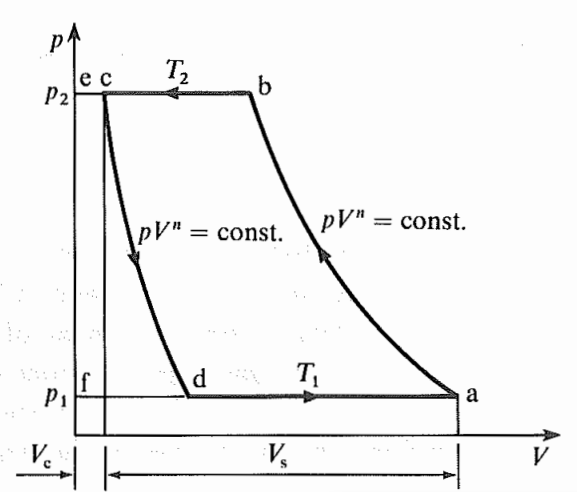

(Eastop & McConkey, 2006)

Cuando se completa la carrera de entrega $bc$, el volumen residual $V_e$ está lleno de gas a una presión $p_2$ y una temperatura $T_2$.

A medida que el pistón avanza en la siguiente carrera de inducción, el aire se expande detrás de él hasta que se alcance la presión $p_1$.

Idealmente, tan pronto como la presión alcance $p_1$, comenzará la inducción de gas fresco y continuará hasta el final de esta carrera en $a$.

El gas se comprime entonces de acuerdo con la ley $pV^n = cte$, y la entrega comienza en $b$, controlada por las válvulas.

El efecto del volumen residual es reducir el volumen inducido en $p_1$ y $T_1$ de $V_s$ a ($V_a -V_b$). Las masa de gas en los cuatro puntos principales son tales que $\dot{m}_c = \dot{m}_d$ y $\dot{m}_b = \dot{m}_c$.

La masa entregada por unidad de tiempo se da por $(\dot{m}_b = \dot{m}_c)$, que es igual a la inducida, dada por ($\dot{m}_a = \dot{m}_d$). Las propiedades del fluido de trabajo cambian en los procesos a-b y c-d.

Podemos deducir la ecucación del trabajo de la misma manera que lo hicimos para el compresor simple con lo que  la potencia con un volumen residual sera:

$$ \dot{W} \ = \frac{n}{n-1}\dot{m_a}(T_2-T_1)-\frac{n}{n-1}\dot{m_d}(T_2-T_1)\\
= \frac{n}{n-1} R \dot{m}(T_2-T_1)$$

Donde $̇\dot{m}$ es la masa inducida por unidad de tiempo

Una comparación entre las ecuaciones, muestra que son idénticas. El trabajo realizado en la compresión de la masa de gas $\dot{m}_c$ o $\dot{m}_d$ en la compresión, de $a$ a $b$, se devuelve cuando el gas se expande de $c$ a $d$. Por lo tanto, el trabajo realizado por unidad de masa de aire entregada no se ve afectado por el tamaño del volumen residual.

Podemos ademas reescribir la expresion de la forma:

$$\dot{W} \ = \frac{n}{n-1}p_1 \dot{V} \left[ \left( \frac{p_2}{p_1}\right)^{(n-1)/n}-1 \right]$$


Además, si hay $f$ ciclos por unidad de tiempo, entonces tenemos

$$\dot{W} \ = \frac{n}{n-1}p_1 f(V_a-V_d) \left[ \left( \frac{p_2}{p_1}\right)^{(n-1)/n}-1 \right]$$

__Nota:__
La masa entregada por unidad de tiempo puede aumentarse diseñando la máquina para que sea de doble efecto, es decir, el gas se maneja en ambos lados del pistón, la carrera de inducción para un lado es la carrera de compresión para el otro.

##3. Eficiencia Volumétrica $\eta_v$




Se ha demostrado que uno de los efectos del volumen residual es reducir el volumen inducido a un valor menor que el volumen barrido. Esto significa que, para una inducción requerida, el tamaño del cilindro debe aumentarse en comparación con el calculado asumiendo un espacio muerto nulo. La eficiencia volumétrica se define de la siguiente manera:

$\eta_v$ = la masa de gas entregada, dividida por la masa de gas que llenaría el volumen barrido en las condiciones de presión y temperatura del aire libre

o

$\eta_v$ = el volumen de gas entregado medido a la presión y temperatura del aire libre, dividido por el volumen barrido del cilindro (12.15)

El volumen de aire tratado por unidad de tiempo por un compresor de aire se cita como la entrega de aire libre (FAD, por sus siglas en inglés), y es la tasa de flujo de volumen entregado, medido a la presión y temperatura de la atmósfera en la que se encuentra la máquina.

Las dos expresiones para $\eta_v$ pueden demostrarse como idénticas, es decir, si el FAD por ciclo es $V$, a una presión $p$ y temperatura $T$, entonces la masa entregada por ciclo es:

$m = \frac{pV}{RT}$

La masa necesaria para llenar el volumen barrido, $V_s$ , a una presión $p$ y temperatura $T$ se da por:

$m_s = \frac{p V_s}{RT}$

por lo tanto:

$$\eta_v = \frac{m}{m_s}= \frac{pV}{RT} \times \frac{RT}{pV_s}= \frac{V}{V_s}  $$

La eficiencia volumétrica se puede obtener a partir del diagrama $p$-$V$ .


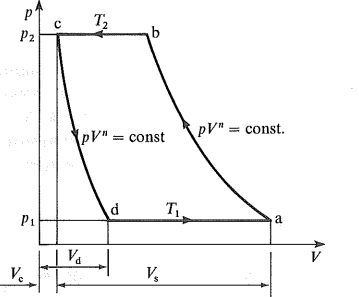

Sabemos que:

$$\frac{V_d}{V_c}=\left(\frac{p_2}{p_1}\right)^{1/n} ⇒ V_d = V_c \left(\frac{p_2}{p_1} \right)^{1/n}$$

Definimos el volumen inducido como
$$V_{ind}=V_a-V_d=V_s-V_c-V_d$$

$$V_{ind}=V_s+V_c-V_c\left(\frac{p_2}{p_1}\right)^{1/n}$$
$$=V_s - V_c \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]$$

Asi podremos re escribir la eficienciencia volumétrica como :

$$\eta_v = \frac{V_a-V_d}{V_s}=\frac{V_s-V_c \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]}{V_s}$$

$$\eta_v = 1- \frac{V_c}{V_s} \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]$$


Es importante destacar que esta definición de eficiencia volumétrica solo es consistente  si las condiciones de presión y temperatura en el cilindro durante la carrera de inducción son idénticas a las del aire libre. De hecho, el gas se calentará debido a las paredes del cilindro y habrá una reducción en la presión debido a la caída de presión necesaria para inducir el gas en el cilindro contra la resistencia al flujo. Estas modificaciones al caso ideal requieren una aplicación más cuidadosa de las fórmulas previamente derivadas.

##4. Ciclo real de compresión


__Ciclo real de compresión__

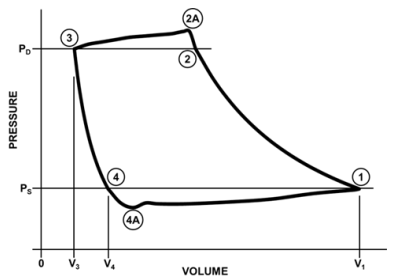

(Phillippi,2016)

Podemos representar un ciclo real tipico de un compresor mediante el diagrama $p$-$V$ anterior donde :

En la posición 1 tiene el volumen máximo $V_1$ de gas atrapado en la cámara de compresión y ese gas está a presión y temperatura de succión. En esta posición tambien, todas las válvulas del compresor están cerradas y el pistón está en reposo. Todas las válvulas del compresor son válvulas de retención simples con resorte y no son accionadas por ningún medio externo. A medida que el cigüeñal gira, el pistón se moverá y el volumen dentro de la cámara de compresión disminuirá (pasando de la Posición 1 a la 2).

Desde la Posición 1, a medida que el volumen disminuye, la presión del gas aumenta. Cuando la presión dentro de la cámara de compresión se vuelve ligeramente mayor que la presión de descarga $2A$, la válvula de descarga del compresor se abrirá.


En la Posición 2, la válvula de descarga se abre y, mientras el pistón sigue moviéndose, el gas a presión y temperatura de descarga es expulsado de la cámara de compresión a través de la válvula de descarga del compresor y hacia el conducto de gas de descarga del cilindro.

En la Posición 3, el pistón se detiene, la válvula de descarga del compresor se cierra.

En la Posición 4, la presión dentro de la cámara de compresión será ligeramente menor que la presión de succión (PS), lo que hará que la válvula de succión del compresor se abra. Con la válvula de succión abierta, la cámara de compresión queda abierta al conducto de gas de succión y, a medida que el pistón continúa moviéndose, el volumen sigue aumentando y la cámara de compresión se llena de gas a presión y temperatura de succión. El pistón vuelve a la Posición 1, se detiene y el proceso se repite

###4.1 Eficiencia Volumétrica

Apartir del diagrama $p$-$V$ podemos definir $\eta_v$ introducciendo nuevos terminos ahora como:

$$\eta_v = 1-\frac{V_c}{V_s}\left[\frac{Z_s}{Z_d}\left(\frac{p_d}{p_s} \right)^{1/n}-1 \right]$$

Donde:
- ZS = Factor de compresibilidad @ PS & TS
- ZD = Factor de compresibilidad @ PD & TD
- PD = Presión de descarga, absoluta
- PS = Presión de succión, absoluta
- n = Exponente adiabático

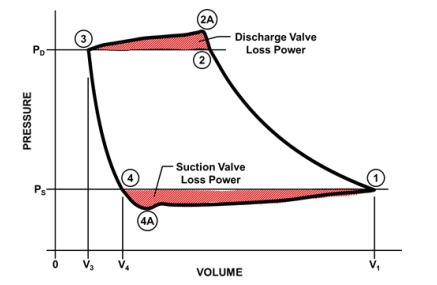

##5. Multietapas de compresión
La eficiencia volumétrica puede mejorarse llevando a cabo la compresión en dos etapas. Después de la primera etapa de compresión, el fluido se pasa a un cilindro más pequeño en el que el gas se comprime a la presión final requerida. Si la máquina tiene dos etapas, el gas se entregará al final de esta etapa, pero podría entregarse a un tercer cilindro para relaciones de presión más altas. Los cilindros de las etapas sucesivas se dimensionan para tomar el volumen de gas entregado desde la etapa anterior


__Diagrama de fase para un compresor de dos etapas__

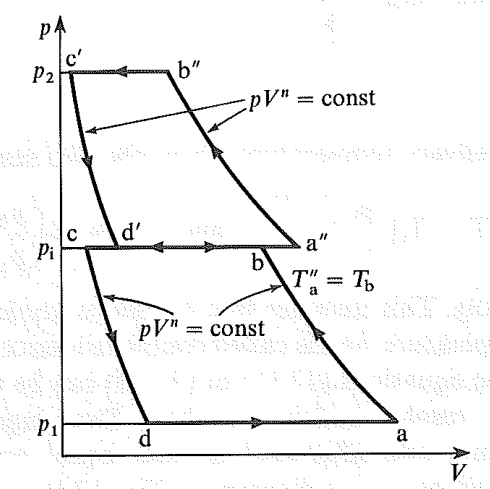

(Eastop & McConkey, 2006)

La compresión isoterma ideal solo se puede lograr si el enfriamiento ideal es continuo. Esto es difícil de lograr durante la compresión normal. Con la compresión multietapa, surge la oportunidad de enfriar el gas mientras se transfiere de un cilindro al siguiente, al hacerlo pasar por un intercooler. Si el interenfriamiento es completo, el gas ingresará a la segunda etapa a la misma temperatura a la que ingresó a la primera etapa. El ahorro de trabajo obtenido mediante el interenfriamiento se muestra en el área sombreada en la Figura. Los dos diagramas de fase $abcd$ y $a'b'c'd'$ se muestran con una presión común, pi. Esto no ocurre en una máquina real ya que hay una pequeña caída de presión entre los cilindros.


__Diagrama de fase para un compresor de dos etapas con intercooler__

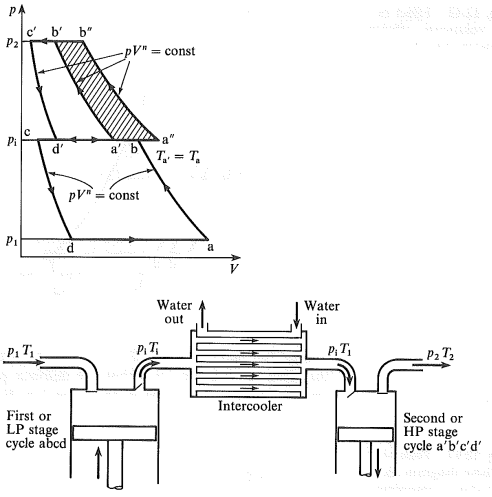

(Eastop & McConkey, 2006)

La temperatura de entrega entre los dos estados esta dado por :

$$T_i=T_1\left(\frac{p_i}{p_1}\right)^{(n-1)/n} \ \text{y}\ \ T_2 = T_1 \left(\frac{p_2}{p_1}\right)^{(n-1)/n}  $$

###5.1 Presión ideal intermedia




El valor elegido para la presión intermedia $p_i$ influye en el trabajo que se debe realizar sobre el gas y su distribución entre las etapas. La condición para que el trabajo realizado sea mínimo se demostrará para la compresión de dos etapas, pero puede extenderse a cualquier número de etapas.

Trabajo total = Trabajo de la etapa LP + Trabajo de la etapa HP.

Asi pues la potencia de compresión total  esta dada por.

$$\dot{W}= \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}-1 \right] + \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_2}{p_i}\right)^{(n-1)/n}-1 \right] $$

$$\dot{W} = \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}-1 +\left( \frac{p_2}{p_i}\right)^{(n-1)/n}-1\right]$$


Si $p_1$ , $T_1$ y $p_2$ son fijos el valor optimo de $p_i$  hace que la potencia sea minima cuando:

 $$\frac{d\dot{W}}{dp_i} = 0$$

 porlo que el valor de $p_i$ es minimo cuando:

 $$\frac{d}{dp_i}\left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}+\left( \frac{p_2}{p_i}\right)^{(n-1)/n}-2\right] = 0$$

  $$\frac{d}{dp_i}\left[ \left( \frac{1}{p_1}\right)^{(n-1)/n}p_i^{(n-1)/n}+p_2^{(n-1)/n}\left( \frac{1}{p_i}\right)^{(n-1)/n}-2\right] = 0$$
$$p_1^{-(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(n-1)/n-1} +p_2^{(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(n-1)/n-1}=0$$

$$p_1^{-(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{-1/n}=p_2^{(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(1-2n)/n}$$

por lo tanto:
$$p_i^{2(n-1)/n} = (p_1p_2)^{(n-1)/n}  $$

y

$$p_i =p_1p_2$$

o

$$\frac{p_i}{p_1} =\frac{p_2}{p_i}$$

Lo que quiere decir que la relación de presion en ambas etapas es la misma

$$\dot{W}_{min} = 2 \dot{W}$$

$$=2 \frac{n\dot{m}RT_1}{n-1} \left[\left(\frac{p_i}{p_1}\right)^{(n-1)/2n}-1\right]$$

O escribiendo en terminos de la relación de presión $p_2/p_1$

$$\frac{p_i}{p_1}=\frac{\sqrt{p_1p_2}}{p_1}= \sqrt{\frac{p_2}{p_1}}$$

Con lo que:

$$\dot{W}_{min}= 2 \frac{n\dot{m}RT_1}{n-1} \left[\left(\frac{p_2}{p_1}\right)^{(n-1)/2n}-1\right]$$

se puede demostrar extendiendo para z etapas de compresión.

$$\dot{W}_{min}= z \frac{n}{n-1} \dot{m}RT_1\left[\left(\frac{p_2}{p_1}\right)^{(n-1)/zn}-1\right]$$

la relación de presion para cada etapa sera.

$$\left(\frac{p_2}{p_1}\right)^{1/z}$$


##6. Eficiencia del compresor

###6.1 Eficiencia Isentrópica

La eficiencia isentrópica de un compresor se define como la relación entre el trabajo de entrada requerido para elevar la presión de un gas a un valor especificado de una manera isentrópica y el trabajo de entrada real:

$$\eta_c = \frac{\text{Trabajo isentrópico del compresor}}{\text{Trabajo real del compresor}}$$




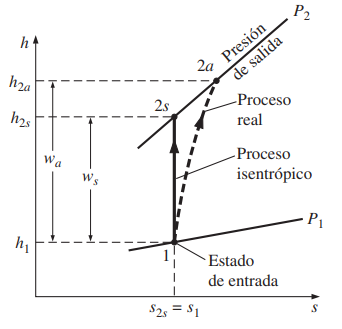

(Çengel et al., 2015)

Cuando son insignificantes los cambios de energía potencial y cinética del gas mientras éste es comprimido, el trabajo de entrada para un compresor adiabático, el trabajo de entrada para un compresor adiabático es igual al cambio de entalpía, por lo que para este caso la ecuación de rendimiento adquiere la forma.

$$ \eta_c =\frac{W_{isen}}{W_{real}}=\frac{h_{2 \ isen}-h_1}{h_{2 \ real}-h_1}$$

Donde $h_{2 \ isen}$  y $h_{2 \ real}$ son los valores de la entalpía en el estado de salida para los procesos de compresión isentrópico y real, respectivamente, como se ilustra en la figura.

El calor de la eficiencia isentrópica depende en gran medida del diseño del compresor. Los compresores mejor diseñados tienen eficiencias isentrópicas de 80 a 90%

##7. Otros Compresores (Rotacionales)



Recordar cómo es la descripción de las máquinas hidráulicas rotacionales: Compresores axiales, compresores centrífugos y turbinas.

###7.1. Tipo Roots



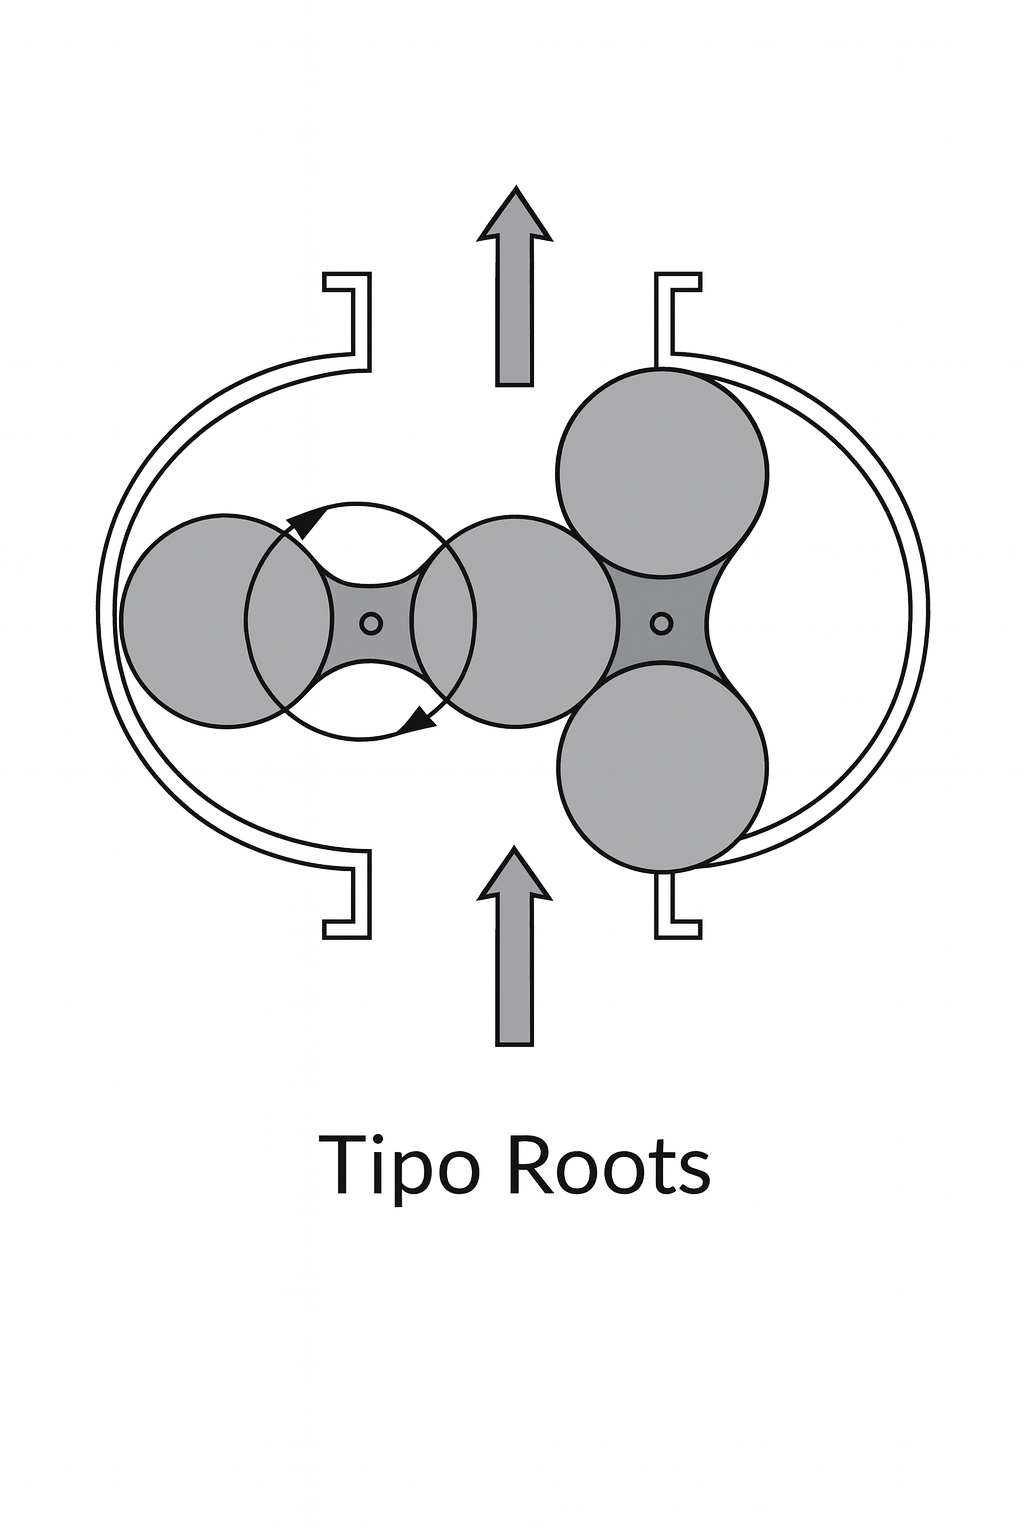

###7.2. Tipo Lysholm

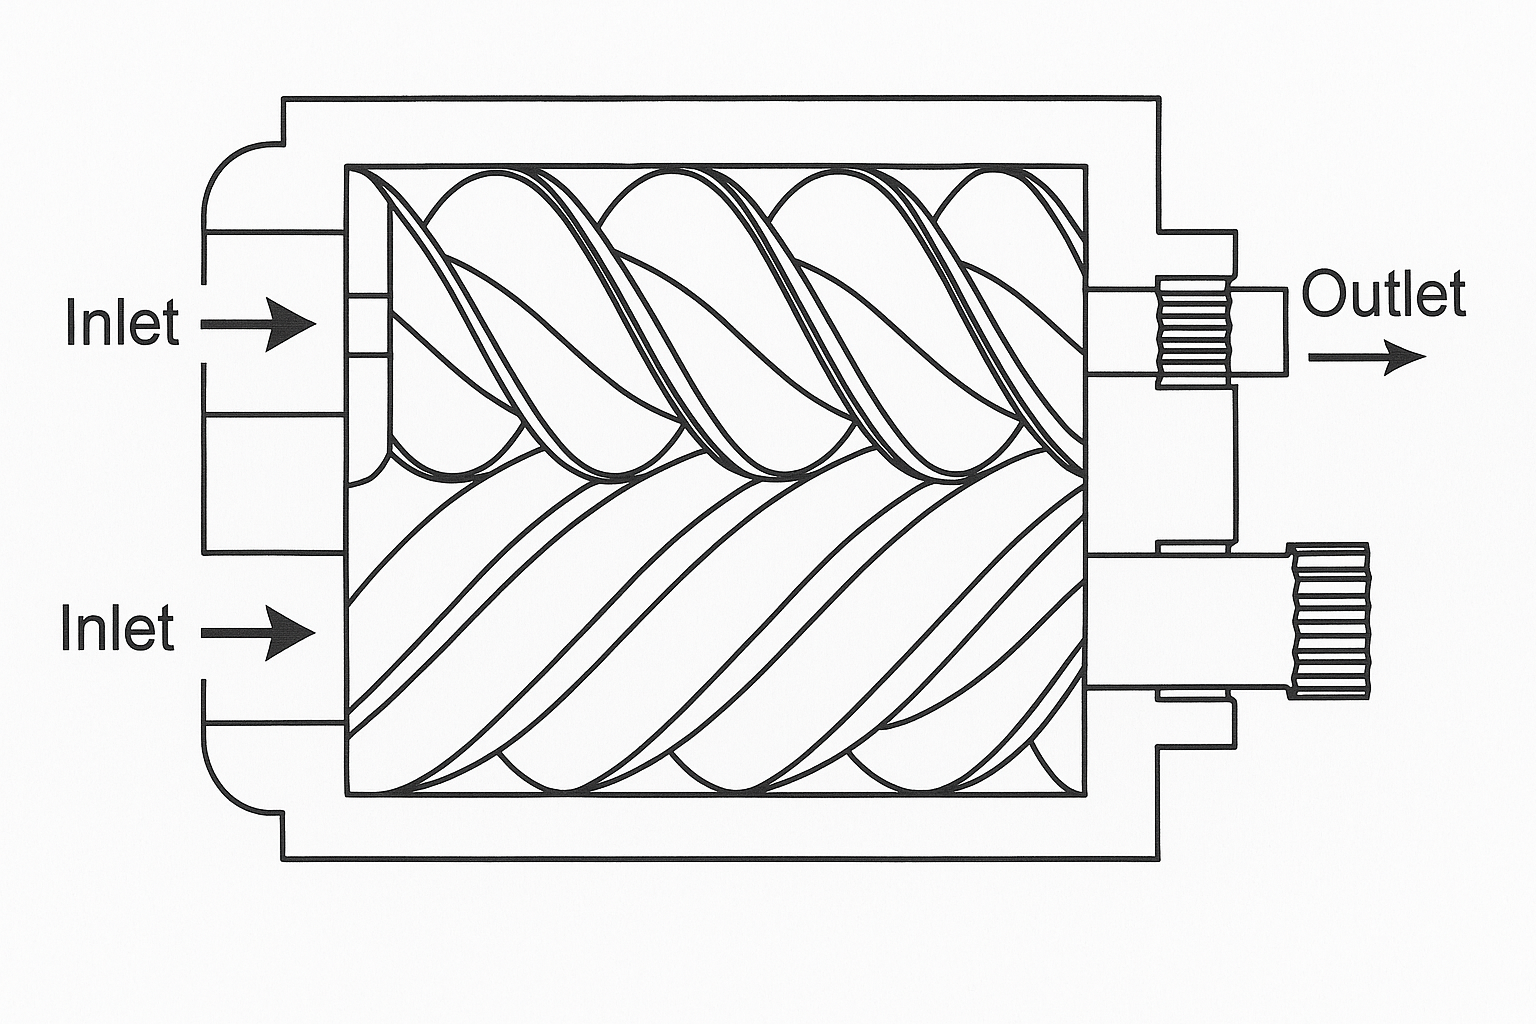

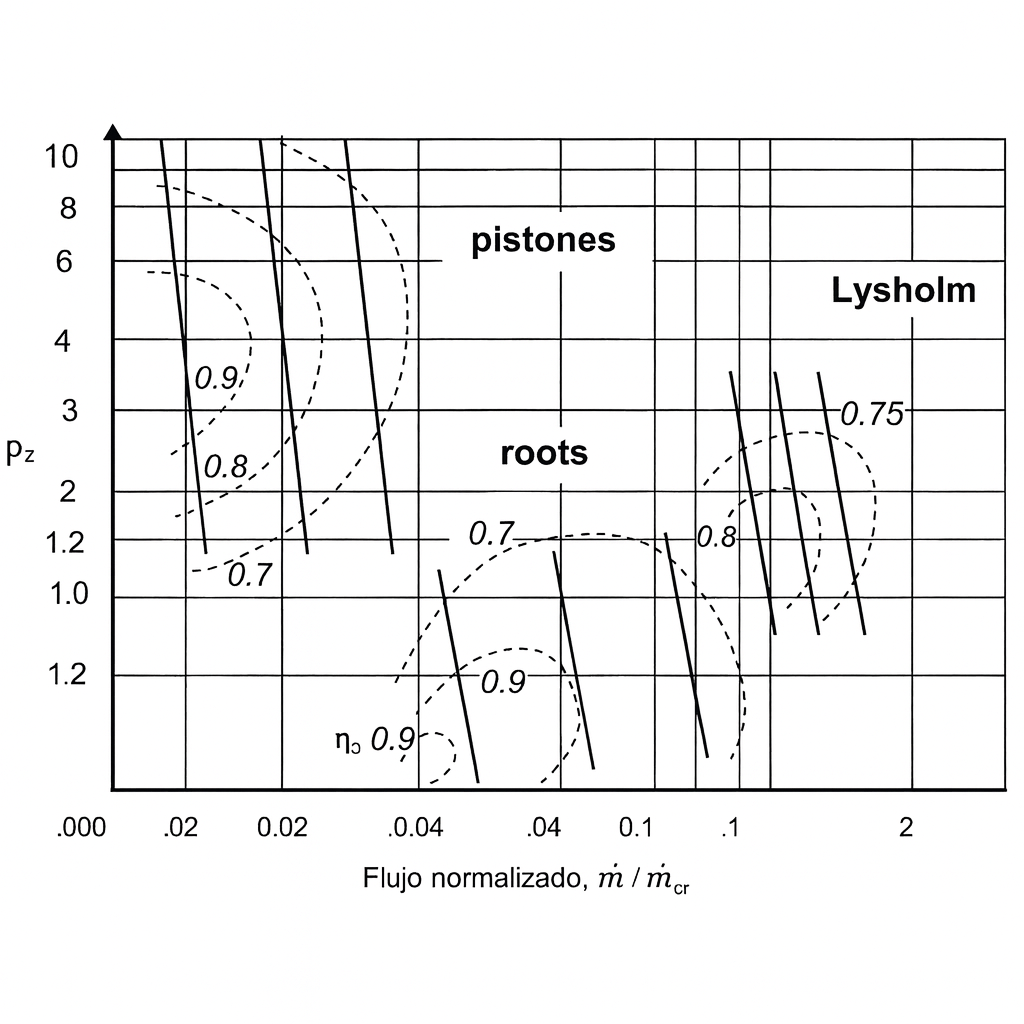

##8. Referencias

Eastop, T. D., & McConkey, A. (2006). Applied Thermodynamics for Engineering Technologists. Pearson/Prentice Hall.

Çengel, Y. A., Buesa, A. I., & ; Boles, M. A. (2015). Termodinámica. McGraw Hill.

Phillippi,G. (2016). Basic Thermodynamics Of Reciprocating Compression. Turbomachinery Laboratories, Texas A&M Engineering Experiment Station. Available electronically from https : / /hdl .handle .net /1969 .1 /159804.